# DOCVQA: GraphColBERT + FiLM

Самостоятельный end-to-end эксперимент. Весь проектный код находится в ячейках этого ноутбука.

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import asdict, dataclass
from collections import defaultdict
from typing import Any, Dict, Iterable, Mapping, Optional, Sequence, Set
import argparse
import inspect
import json
import math
import os
import random
import re
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
from sentence_transformers import SentenceTransformer
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.nn import GATv2Conv, GlobalAttention, TransformerConv
from torch_geometric.utils import to_dense_batch
from tqdm.auto import tqdm


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for candidate in (base, base / "diagram_vqa"):
            if (candidate / "notebooks/experiments").exists() and (candidate / "runs").exists():
                return candidate
    raise FileNotFoundError("diagram_vqa project root was not found")


ROOT = find_project_root()
EXTERNAL_ROOT = ROOT.parent
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

DATASET = 'docvqa'
ARCHITECTURE = 'graphcolbert_film'
MODEL_NAME = 'graphcolbert_film'
MODEL_TITLE = 'GraphColBERT + FiLM'
SEED = 42
EPOCHS = 23
BATCH_SIZE = 8
EVAL_BATCH_SIZE = 128
RUN_DIR = ROOT / "runs/docvqa/graphcolbert_film/seed42_full"
RUN_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print({"dataset": DATASET, "architecture": ARCHITECTURE, "epochs": EPOCHS, "run_dir": str(RUN_DIR)})


device: cuda
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
{'dataset': 'docvqa', 'architecture': 'graphcolbert_film', 'epochs': 23, 'run_dir': 'C:\\Users\\Jet\\Desktop\\data\\diagram_vqa\\runs\\docvqa\\graphcolbert_film\\seed42_full'}


## Dataset Format and Metrics

In [2]:
def recall_at_k_from_sim(sim: Sequence[Sequence[float]], ks: Iterable[int] = (1, 5, 10)) -> Dict[int, float]:
    rows = [list(r) for r in sim]
    if not rows:
        raise ValueError("sim must be non-empty")
    n = len(rows)
    if any(len(r) != n for r in rows):
        shape = (len(rows), len(rows[0]) if rows else 0)
        raise ValueError(f"sim must be square [N, N], got {shape}")

    out: Dict[int, float] = {}
    for k in ks:
        if int(k) <= 0:
            raise ValueError(f"k must be positive, got {k}")
        k_eff = min(int(k), n)
        hits = 0
        for i, row in enumerate(rows):
            top_idx = sorted(range(n), key=lambda j: row[j], reverse=True)[:k_eff]
            if i in top_idx:
                hits += 1
        out[int(k)] = hits / n
    return out


def recall_at_k_multi_positive(
    sim: Sequence[Sequence[float]],
    positive_indices: Sequence[Iterable[int]],
    ks: Iterable[int] = (1, 5, 10),
) -> Dict[int, float]:
    """Compute Recall@K for rectangular similarities with one or more positives.

    ``positive_indices[i]`` contains the candidate indices that are correct for
    query row ``i``. Queries without a positive candidate are rejected because
    silently counting them as misses makes split/manifest errors hard to spot.
    """
    rows = [list(row) for row in sim]
    if not rows:
        raise ValueError("sim must be non-empty")
    width = len(rows[0])
    if width == 0 or any(len(row) != width for row in rows):
        raise ValueError("sim must be a non-empty rectangular matrix")
    if len(positive_indices) != len(rows):
        raise ValueError("positive_indices must contain one entry per query")

    positives: list[set[int]] = []
    for query_idx, values in enumerate(positive_indices):
        current = {int(value) for value in values}
        if not current:
            raise ValueError(f"query {query_idx} has no positive candidate")
        if min(current) < 0 or max(current) >= width:
            raise ValueError(f"query {query_idx} contains an out-of-range positive index")
        positives.append(current)

    ranked = [sorted(range(width), key=lambda idx: row[idx], reverse=True) for row in rows]
    out: Dict[int, float] = {}
    for k in ks:
        if int(k) <= 0:
            raise ValueError(f"k must be positive, got {k}")
        k_eff = min(int(k), width)
        hits = sum(bool(set(order[:k_eff]) & positive) for order, positive in zip(ranked, positives))
        out[int(k)] = hits / len(rows)
    return out


def mean_reciprocal_rank_multi_positive(
    sim: Sequence[Sequence[float]],
    positive_indices: Sequence[Iterable[int]],
) -> float:
    """Return MRR using the rank of the first relevant candidate per query."""
    rows = [list(row) for row in sim]
    positives = [{int(value) for value in values} for values in positive_indices]
    # Reuse validation, including the no-positive invariant.
    recall_at_k_multi_positive(rows, positives, ks=(1,))
    reciprocal_ranks = []
    for row, relevant in zip(rows, positives):
        order = sorted(range(len(row)), key=lambda idx: row[idx], reverse=True)
        rank = next(rank for rank, idx in enumerate(order, start=1) if idx in relevant)
        reciprocal_ranks.append(1.0 / rank)
    return sum(reciprocal_ranks) / len(reciprocal_ranks)

PUBLIC_VQA_TARGETS: dict[str, dict[str, Any]] = {
    "ai2d": {
        "metric": "accuracy",
        "primary_target": 0.947,
        "stretch_target": 0.9602,
        "qwen25_vl_3b_baseline": 0.815,
        "sources": [
            "https://evalscope.readthedocs.io/en/latest/benchmarks/ai2d.html",
            "https://llm-stats.com/benchmarks/ai2d",
            "https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct/blob/main/README.md",
        ],
    },
    "docvqa": {
        "metric": "anls",
        "primary_target": 0.964,
        "stretch_target": None,
        "qwen25_vl_3b_baseline": 0.939,
        "sources": [
            "https://www.docvqa.org/challenges/challenge-2020",
            "https://huggingface.co/Qwen/Qwen2.5-VL-72B-Instruct",
            "https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct/blob/main/README.md",
        ],
    },
    "infographicvqa": {
        "metric": "anls",
        "primary_target": 0.834,
        "stretch_target": 0.873,
        "qwen25_vl_3b_baseline": 0.771,
        "aliases": ["infovqa", "infographicsvqa"],
        "sources": [
            "https://www.docvqa.org/datasets/infographicvqa",
            "https://evalscope.readthedocs.io/en/latest/benchmarks/infovqa.html",
            "https://llm-stats.com/benchmarks/infovqa",
            "https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct/blob/main/README.md",
        ],
    },
}

_ALIASES = {
    alias: dataset
    for dataset, payload in PUBLIC_VQA_TARGETS.items()
    for alias in payload.get("aliases", [])
}

_PUNCT_RE = re.compile(r"[^\w\s\.\-/%]", flags=re.UNICODE)
_SPACE_RE = re.compile(r"\s+")


@dataclass(frozen=True)
class PublicVqaSampleResult:
    sample_id: str
    dataset: str
    metric: str
    raw_prediction: str
    prediction: str
    normalized_prediction: str
    gold_answers: tuple[str, ...]
    normalized_gold_answers: tuple[str, ...]
    score: float
    error_slice: str

    def to_dict(self) -> dict[str, Any]:
        payload = asdict(self)
        payload["gold_answers"] = list(self.gold_answers)
        payload["normalized_gold_answers"] = list(self.normalized_gold_answers)
        return payload


def canonical_dataset_name(dataset_name: str) -> str:
    key = str(dataset_name).strip().lower().replace("-", "").replace("_", "")
    if key in PUBLIC_VQA_TARGETS:
        return key
    if key in _ALIASES:
        return _ALIASES[key]
    raise ValueError(f"Unsupported public VQA dataset: {dataset_name}")


def target_for_dataset(dataset_name: str) -> dict[str, Any]:
    key = canonical_dataset_name(dataset_name)
    return PUBLIC_VQA_TARGETS[key]


def normalize_answer(text: Any) -> str:
    value = str(text or "").strip().lower()
    value = value.replace("\u2013", "-").replace("\u2014", "-")
    value = value.replace(",", "")
    value = _PUNCT_RE.sub(" ", value)
    return _SPACE_RE.sub(" ", value).strip()


def levenshtein_distance(left: str, right: str) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)
    if len(left) < len(right):
        left, right = right, left

    prev = list(range(len(right) + 1))
    for i, left_ch in enumerate(left, start=1):
        curr = [i]
        for j, right_ch in enumerate(right, start=1):
            cost = 0 if left_ch == right_ch else 1
            curr.append(min(curr[-1] + 1, prev[j] + 1, prev[j - 1] + cost))
        prev = curr
    return prev[-1]


def normalized_levenshtein_similarity(prediction: str, gold: str, threshold: float = 0.5) -> float:
    pred_norm = normalize_answer(prediction)
    gold_norm = normalize_answer(gold)
    if not pred_norm and not gold_norm:
        return 1.0
    if not pred_norm or not gold_norm:
        return 0.0
    norm_dist = levenshtein_distance(pred_norm, gold_norm) / max(len(pred_norm), len(gold_norm))
    if norm_dist >= threshold:
        return 0.0
    return 1.0 - norm_dist


def anls_score(prediction: str, gold_answers: Sequence[str], threshold: float = 0.5) -> float:
    if not gold_answers:
        return 0.0
    return max(normalized_levenshtein_similarity(prediction, gold, threshold=threshold) for gold in gold_answers)


def accuracy_score(prediction: str, gold_answers: Sequence[str]) -> float:
    pred_norm = normalize_answer(prediction)
    return float(bool(pred_norm) and any(pred_norm == normalize_answer(gold) for gold in gold_answers))


def public_vqa_score(dataset_name: str, prediction: str, gold_answers: Sequence[str]) -> tuple[str, float]:
    target = target_for_dataset(dataset_name)
    metric = str(target["metric"])
    if metric == "accuracy":
        return metric, accuracy_score(prediction, gold_answers)
    if metric == "anls":
        return metric, anls_score(prediction, gold_answers)
    raise ValueError(f"Unsupported metric for {dataset_name}: {metric}")


def classify_error_slice(
    prediction: str,
    gold_answers: Sequence[str],
    score: float,
    raw_prediction: str = "",
    json_valid: Optional[bool] = None,
    status: str = "",
    ocr_text: str = "",
) -> str:
    if score >= 1.0:
        return "correct"
    if json_valid is False:
        return "invalid_json"
    if str(status).strip().lower() == "failed":
        return "failed_status"

    pred_norm = normalize_answer(prediction)
    if not pred_norm:
        return "empty_answer"

    ocr_norm = normalize_answer(ocr_text)
    gold_norms = [normalize_answer(gold) for gold in gold_answers if normalize_answer(gold)]
    if ocr_norm and gold_norms and not any(gold in ocr_norm for gold in gold_norms):
        return "ocr_miss"

    raw_norm = normalize_answer(raw_prediction)
    if gold_norms and any(gold in raw_norm for gold in gold_norms):
        return "answer_extraction_miss"
    if re.search(r"\d", pred_norm) or any(re.search(r"\d", gold) for gold in gold_norms):
        return "arithmetic_or_numeric_miss"
    return "wrong_answer"


def _row_gold_answers(row: Mapping[str, Any]) -> tuple[str, ...]:
    value = row.get("gold_answers", None)
    if value is None:
        value = row.get("answers", None)
    if isinstance(value, str):
        out = [value]
    elif isinstance(value, Iterable):
        out = [str(item) for item in value if str(item).strip()]
    else:
        out = []

    for key in ("gold_answer", "correct_option_text", "correct_text"):
        if row.get(key) is not None:
            out.append(str(row[key]))
    if row.get("gold_option_text") is not None:
        out.append(str(row["gold_option_text"]))
    dedup: list[str] = []
    for answer in out:
        if answer not in dedup:
            dedup.append(answer)
    return tuple(dedup)


def evaluate_public_vqa_rows(
    rows: Sequence[Mapping[str, Any]],
    dataset_name: str,
) -> tuple[dict[str, Any], list[PublicVqaSampleResult]]:
    dataset = canonical_dataset_name(dataset_name)
    target = target_for_dataset(dataset)
    metric = str(target["metric"])

    sample_results: list[PublicVqaSampleResult] = []
    for idx, row in enumerate(rows):
        prediction = str(
            row.get(
                "pred_answer",
                row.get("pred_option_text", row.get("prediction", row.get("answer", ""))),
            )
            or ""
        )
        raw_prediction = str(row.get("raw_response", row.get("raw_prediction", prediction)) or "")
        gold_answers = _row_gold_answers(row)
        _, score = public_vqa_score(dataset, prediction, gold_answers)
        normalized_gold = tuple(normalize_answer(answer) for answer in gold_answers)
        sample_results.append(
            PublicVqaSampleResult(
                sample_id=str(row.get("sample_id", row.get("questionId", idx))),
                dataset=dataset,
                metric=metric,
                raw_prediction=raw_prediction,
                prediction=prediction,
                normalized_prediction=normalize_answer(prediction),
                gold_answers=gold_answers,
                normalized_gold_answers=normalized_gold,
                score=float(score),
                error_slice=classify_error_slice(
                    prediction=prediction,
                    gold_answers=gold_answers,
                    score=float(score),
                    raw_prediction=raw_prediction,
                    json_valid=row.get("json_valid") if isinstance(row.get("json_valid"), bool) else None,
                    status=str(row.get("status", "")),
                    ocr_text=str(row.get("ocr_text", "")),
                ),
            )
        )

    scores = [result.score for result in sample_results]
    aggregate = sum(scores) / max(1, len(scores))
    primary_target = float(target["primary_target"])
    stretch_raw = target.get("stretch_target")
    stretch_target = float(stretch_raw) if stretch_raw is not None else None
    error_counts: dict[str, int] = {}
    for result in sample_results:
        error_counts[result.error_slice] = error_counts.get(result.error_slice, 0) + 1

    metrics = {
        "dataset": dataset,
        "metric": metric,
        "num_samples": len(sample_results),
        metric: aggregate,
        "score": aggregate,
        "primary_target": primary_target,
        "primary_target_gap": aggregate - primary_target,
        "beats_primary_target": aggregate > primary_target,
        "stretch_target": stretch_target,
        "stretch_target_gap": None if stretch_target is None else aggregate - stretch_target,
        "beats_stretch_target": False if stretch_target is None else aggregate > stretch_target,
        "qwen25_vl_3b_baseline": target.get("qwen25_vl_3b_baseline"),
        "error_slices": error_counts,
        "sources": target.get("sources", []),
    }
    return metrics, sample_results


def write_public_vqa_report(
    metrics: Mapping[str, Any],
    sample_results: Sequence[PublicVqaSampleResult],
    output_dir: str | Path,
    prefix: str = "public_vqa",
) -> dict[str, str]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = output_dir / f"{prefix}_metrics.json"
    predictions_path = output_dir / f"{prefix}_predictions.jsonl"
    errors_path = output_dir / f"{prefix}_error_slices.json"

    metrics_path.write_text(json.dumps(dict(metrics), ensure_ascii=False, indent=2), encoding="utf-8")
    with predictions_path.open("w", encoding="utf-8") as handle:
        for result in sample_results:
            handle.write(json.dumps(result.to_dict(), ensure_ascii=False) + "\n")
    errors_path.write_text(
        json.dumps(metrics.get("error_slices", {}), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return {
        "metrics": str(metrics_path),
        "predictions": str(predictions_path),
        "error_slices": str(errors_path),
    }

DATASETS = ("ai2d", "infographicvqa", "docvqa")
MODELS = (
    "random",
    "clip",
    "siglip",
    "ocr_text",
    "gatv2_knn",
    "graph_transformer",
    "sam2_graph_transformer",
    "hybrid_gatv2_knn",
    "graphcolbert",
    "graphcolbert_film",
    "qwen25_vl_qlora",
)
TRAINABLE_LOCAL_MODELS = MODELS[1:3] + MODELS[4:10]
# The controlled matrix uses one reproducible run per model/dataset.  Older
# seed43/seed44 artifacts are preserved but are no longer scheduled.
SEEDS = (42,)


def manifest_for(dataset: str, external_root: Path) -> Path:
    paths = {
        "ai2d": external_root / "ai2d/model_matrix_v1/manifest.jsonl",
        "infographicvqa": external_root / "infographicvqa/prepared_v1/manifest.jsonl",
        "docvqa": external_root / "docvqa/prepared_v1/manifest.jsonl",
    }
    return paths[dataset]


def load_rows(dataset: str, external_root: Path) -> list[dict[str, Any]]:
    path = manifest_for(dataset, external_root)
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    normalized = []
    for row in rows:
        item = dict(row)
        image_path = Path(str(item["image_path"]))
        if not image_path.is_absolute():
            image_path = external_root / image_path
        item["image_path"] = str(image_path.resolve())
        item["sample_id"] = str(item.get("sample_id", item.get("question_id", len(normalized))))
        item["image_id"] = str(item.get("image_id", item.get("doc_id", image_path.stem)))
        if dataset == "ai2d":
            item["answers"] = [str(item["correct_option_text"])]
        else:
            item["answers"] = [str(value) for value in item.get("answers", [])]
        normalized.append(item)
    return normalized


def ensure_free_space(path: Path, minimum_free_gb: float = 20.0) -> float:
    path.mkdir(parents=True, exist_ok=True)
    free_gb = shutil.disk_usage(path.resolve().anchor).free / (1024**3)
    if free_gb < minimum_free_gb:
        raise RuntimeError(f"Only {free_gb:.2f} GiB free; {minimum_free_gb:.2f} GiB required")
    return free_gb


def split_rows(rows: Sequence[dict[str, Any]], split: str, max_samples: int | None = None) -> list[dict[str, Any]]:
    selected = [row for row in rows if row.get("split") == split]
    return selected[:max_samples] if max_samples is not None else selected


def _bbox_from_polygon(values: Sequence[float]) -> list[float]:
    xs = [float(values[idx]) for idx in range(0, len(values), 2)]
    ys = [float(values[idx]) for idx in range(1, len(values), 2)]
    return [min(xs), min(ys), max(xs), max(ys)] if xs and ys else [0.0, 0.0, 0.0, 0.0]


def _read_ai2d_ocr(row: dict[str, Any], external_root: Path) -> list[dict[str, Any]]:
    path = Path(str(row.get("ocr_v2_path") or ""))
    if not path.is_absolute():
        path = external_root / path
    if not path.exists():
        return []
    payload = json.loads(path.read_text(encoding="utf-8"))
    return [{"text": str(word.get("text", "")), "bbox": word.get("bbox", [0, 0, 0, 0])} for word in payload.get("words", [])]


def _read_azure_ocr(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    payload = json.loads(path.read_text(encoding="utf-8"))
    results = payload.get("recognitionResults") or payload.get("analyzeResult", {}).get("readResults") or []
    spans = []
    for page in results:
        for line in page.get("lines", []):
            polygon = line.get("boundingBox") or line.get("polygon") or []
            spans.append({"text": str(line.get("text", "")), "bbox": _bbox_from_polygon(polygon)})
    return spans


def _tesseract_ocr(row: dict[str, Any], cache_dir: Path) -> list[dict[str, Any]]:
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{row['image_id']}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    import pytesseract

    if pytesseract.pytesseract.tesseract_cmd == "tesseract":
        windows_default = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
        if windows_default.exists():
            pytesseract.pytesseract.tesseract_cmd = str(windows_default)

    image = Image.open(row["image_path"]).convert("RGB")
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT, config="--psm 11")
    spans = []
    for idx, text in enumerate(data.get("text", [])):
        value = str(text).strip()
        if not value:
            continue
        x, y = int(data["left"][idx]), int(data["top"][idx])
        w, h = int(data["width"][idx]), int(data["height"][idx])
        spans.append({"text": value, "bbox": [x, y, x + w, y + h]})
    path.write_text(json.dumps(spans, ensure_ascii=False), encoding="utf-8")
    return spans


def ocr_spans(dataset: str, row: dict[str, Any], external_root: Path, cache_root: Path) -> list[dict[str, Any]]:
    if dataset == "ai2d":
        spans = _read_ai2d_ocr(row, external_root)
    elif dataset == "docvqa":
        spans = _read_azure_ocr(Path(str(row.get("ocr_path", ""))))
    else:
        spans = _tesseract_ocr(row, cache_root / dataset)
    return [span for span in spans if str(span.get("text", "")).strip()]


def candidate_texts(spans: Sequence[dict[str, Any]], max_candidates: int = 256) -> list[str]:
    values = [str(span["text"]).strip() for span in spans if str(span.get("text", "")).strip()]
    candidates: list[str] = []
    for value in values:
        if value not in candidates:
            candidates.append(value)
    # Contiguous line/word windows make extractive evaluation useful for
    # answers that span several OCR tokens without consulting gold labels.
    for size in (2, 3, 4, 5, 6):
        for start in range(max(0, len(values) - size + 1)):
            value = " ".join(values[start : start + size])
            if value not in candidates:
                candidates.append(value)
            if len(candidates) >= max_candidates:
                return candidates
    return candidates[:max_candidates]


def retrieval_metrics(similarity: np.ndarray, question_doc_ids: Sequence[str], document_ids: Sequence[str]) -> dict[str, Any]:
    doc_index = {doc_id: idx for idx, doc_id in enumerate(document_ids)}
    q2d_positive = [{doc_index[doc_id]} for doc_id in question_doc_ids]
    questions_by_doc: dict[str, set[int]] = defaultdict(set)
    for index, doc_id in enumerate(question_doc_ids):
        questions_by_doc[doc_id].add(index)
    d2q_positive = [questions_by_doc[doc_id] for doc_id in document_ids]
    q2d = similarity.tolist()
    d2q = similarity.T.tolist()
    q2d_recall = recall_at_k_multi_positive(q2d, q2d_positive)
    d2q_recall = recall_at_k_multi_positive(d2q, d2q_positive)
    return {
        "question_to_document": {"recall_at_k": {str(k): v for k, v in q2d_recall.items()}, "mrr": mean_reciprocal_rank_multi_positive(q2d, q2d_positive)},
        "document_to_question": {"recall_at_k": {str(k): v for k, v in d2q_recall.items()}, "mrr": mean_reciprocal_rank_multi_positive(d2q, d2q_positive)},
        "mean_recall_at_k": {str(k): (q2d_recall[k] + d2q_recall[k]) / 2 for k in q2d_recall},
    }


def vqa_row(dataset: str, row: dict[str, Any], prediction: str) -> dict[str, Any]:
    answers = list(row.get("answers", []))
    score = accuracy_score(prediction, answers) if dataset == "ai2d" else anls_score(prediction, answers)
    exact = accuracy_score(prediction, answers)
    return {
        "sample_id": row["sample_id"],
        "question_id": row.get("question_id", row["sample_id"]),
        "image_id": row["image_id"],
        "question": row["question"],
        "pred_answer": prediction,
        "gold_answers": answers,
        "score": score,
        "exact": exact,
        "error_slice": classify_error_slice(prediction, answers, score),
    }


def random_vqa_prediction(dataset: str, row: dict[str, Any], train_answers: Sequence[str], rng: random.Random) -> str:
    if dataset == "ai2d":
        options = list(row.get("options", []))
        return str(rng.choice(options)) if options else ""
    return str(rng.choice(train_answers)) if train_answers else ""


## Data Example

,split,questions
0,train,39463
1,val,5349
2,test,5188


unique images: 12767


,sample_id,image_id,question,answers
0,337,xnbl0037_1,what is the date mentioned in this letter?,[1/8/93]


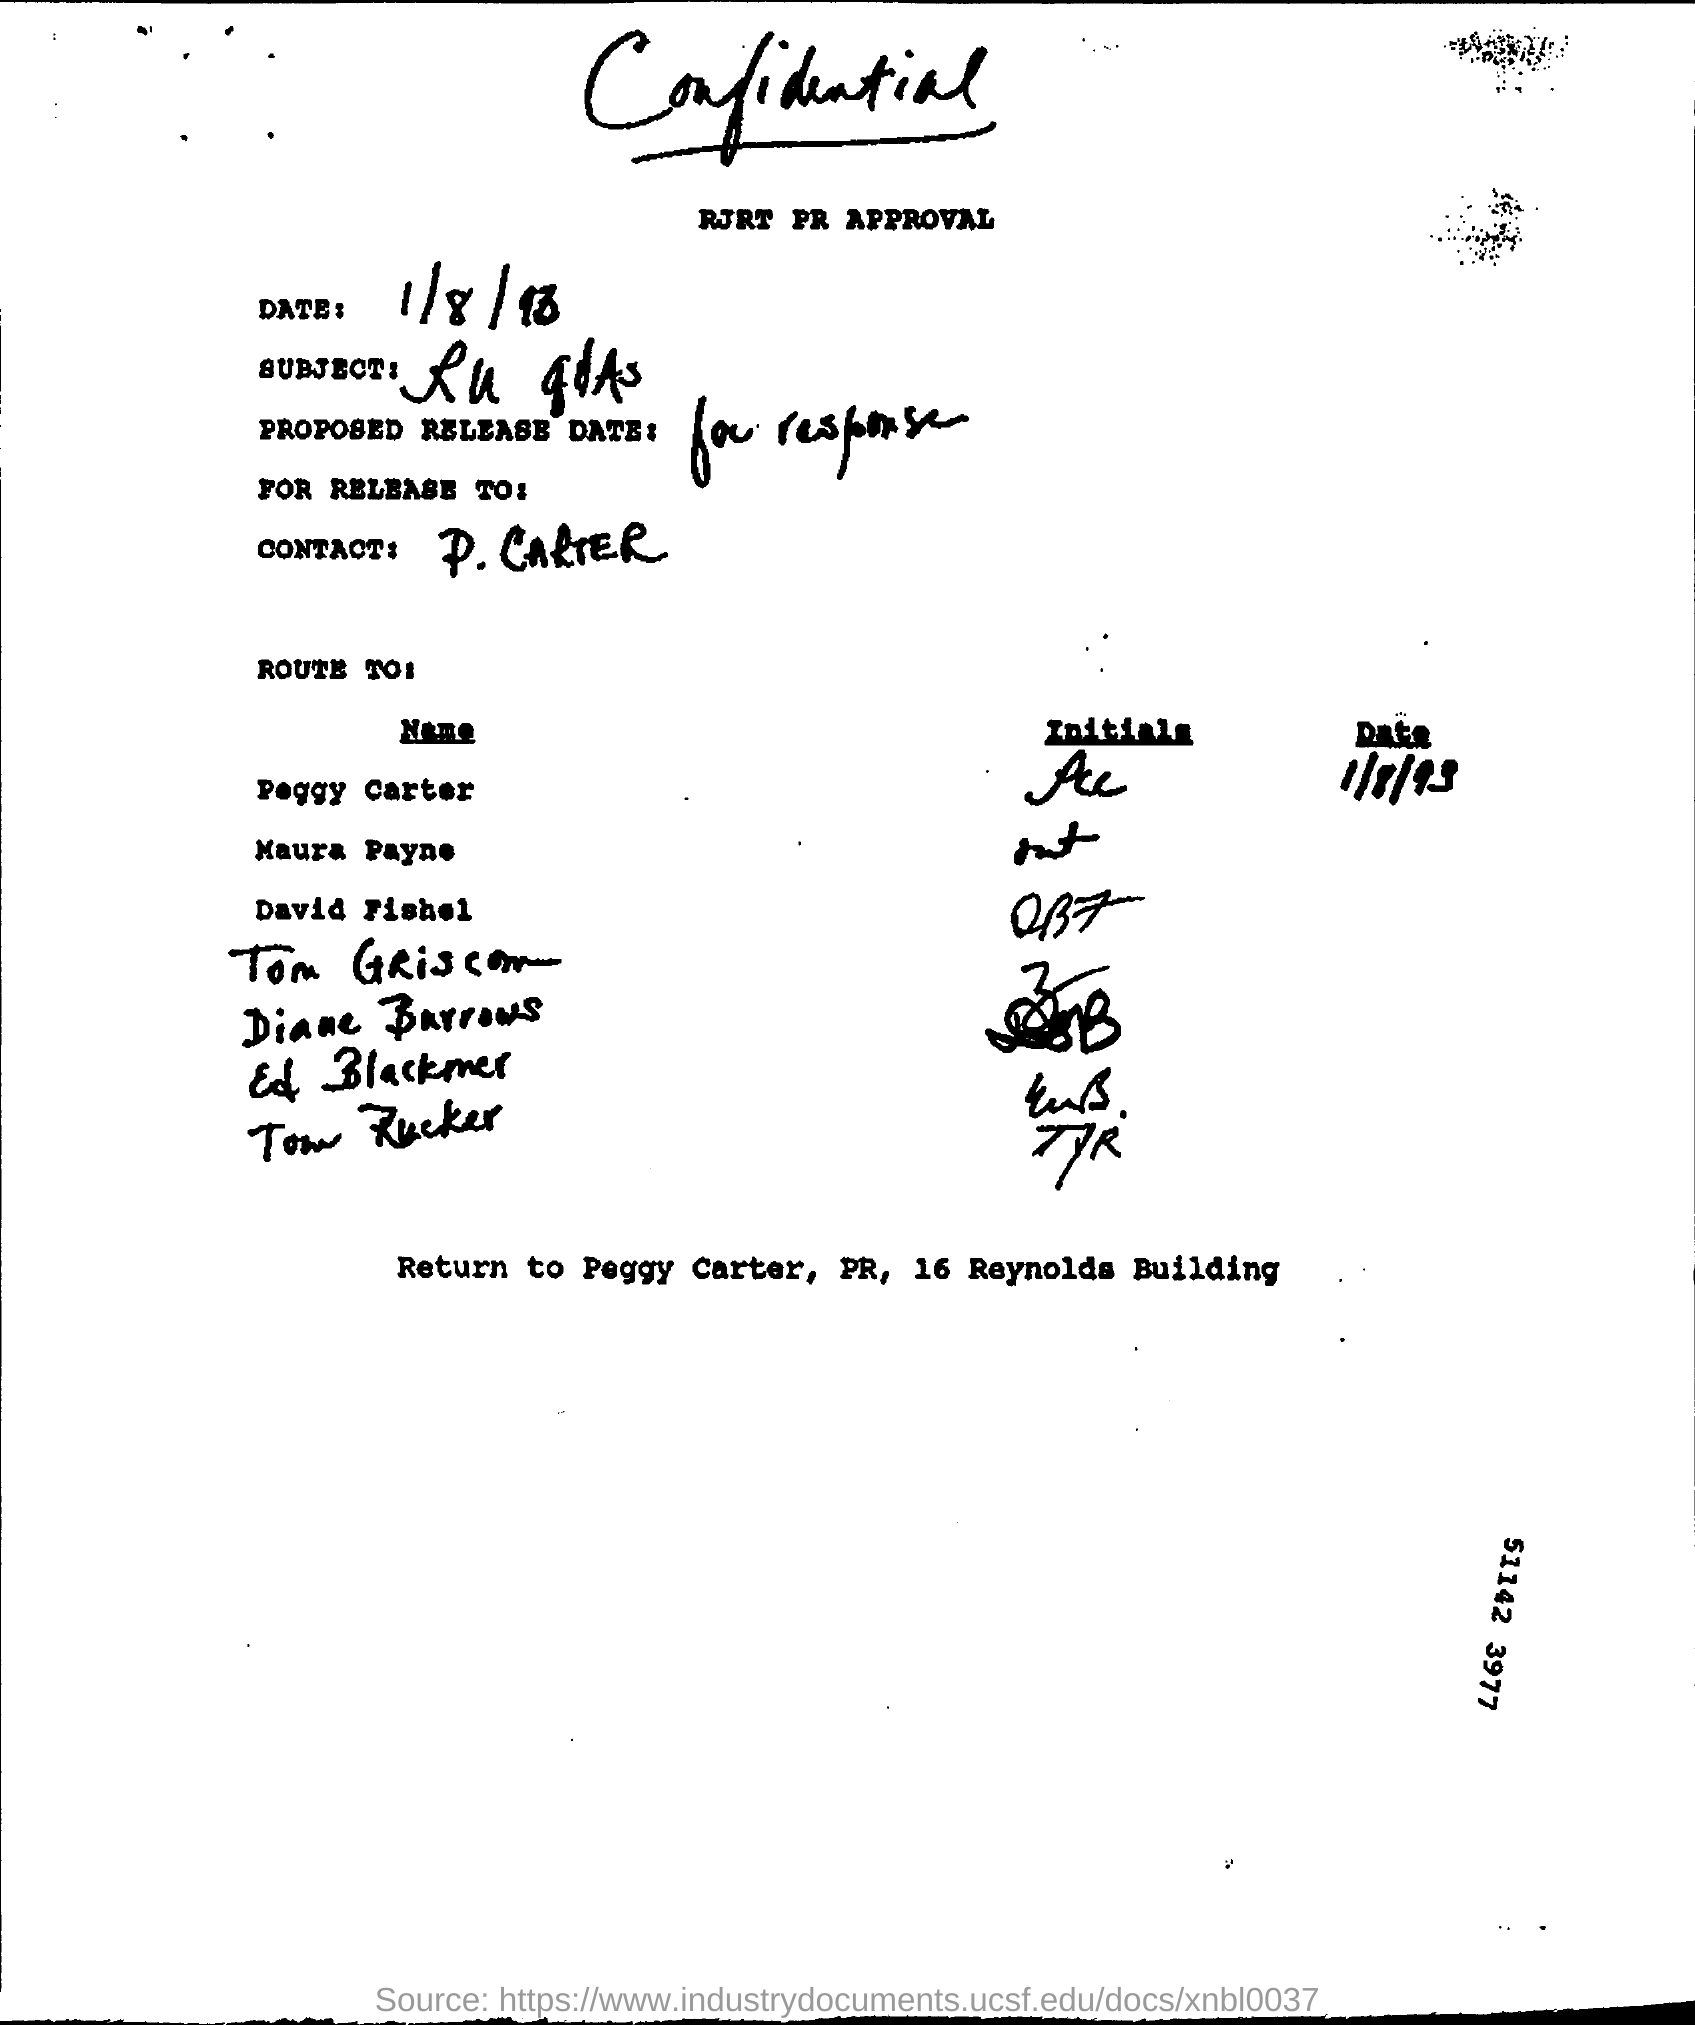

In [3]:
rows = load_rows(DATASET, EXTERNAL_ROOT)
split_counts = pd.Series([row["split"] for row in rows]).value_counts().rename_axis("split").reset_index(name="questions")
unique_images = len({row["image_id"] for row in rows})
display(split_counts)
print("unique images:", unique_images)

train_rows = split_rows(rows, "train")
val_rows = split_rows(rows, "val")
test_rows = split_rows(rows, "test")
sample = next(row for row in train_rows if Path(row["image_path"]).exists())
display(pd.DataFrame([{key: sample.get(key) for key in ("sample_id", "image_id", "question", "answers")}]))
display(Image.open(sample["image_path"]).convert("RGB"))


## Parsed Image

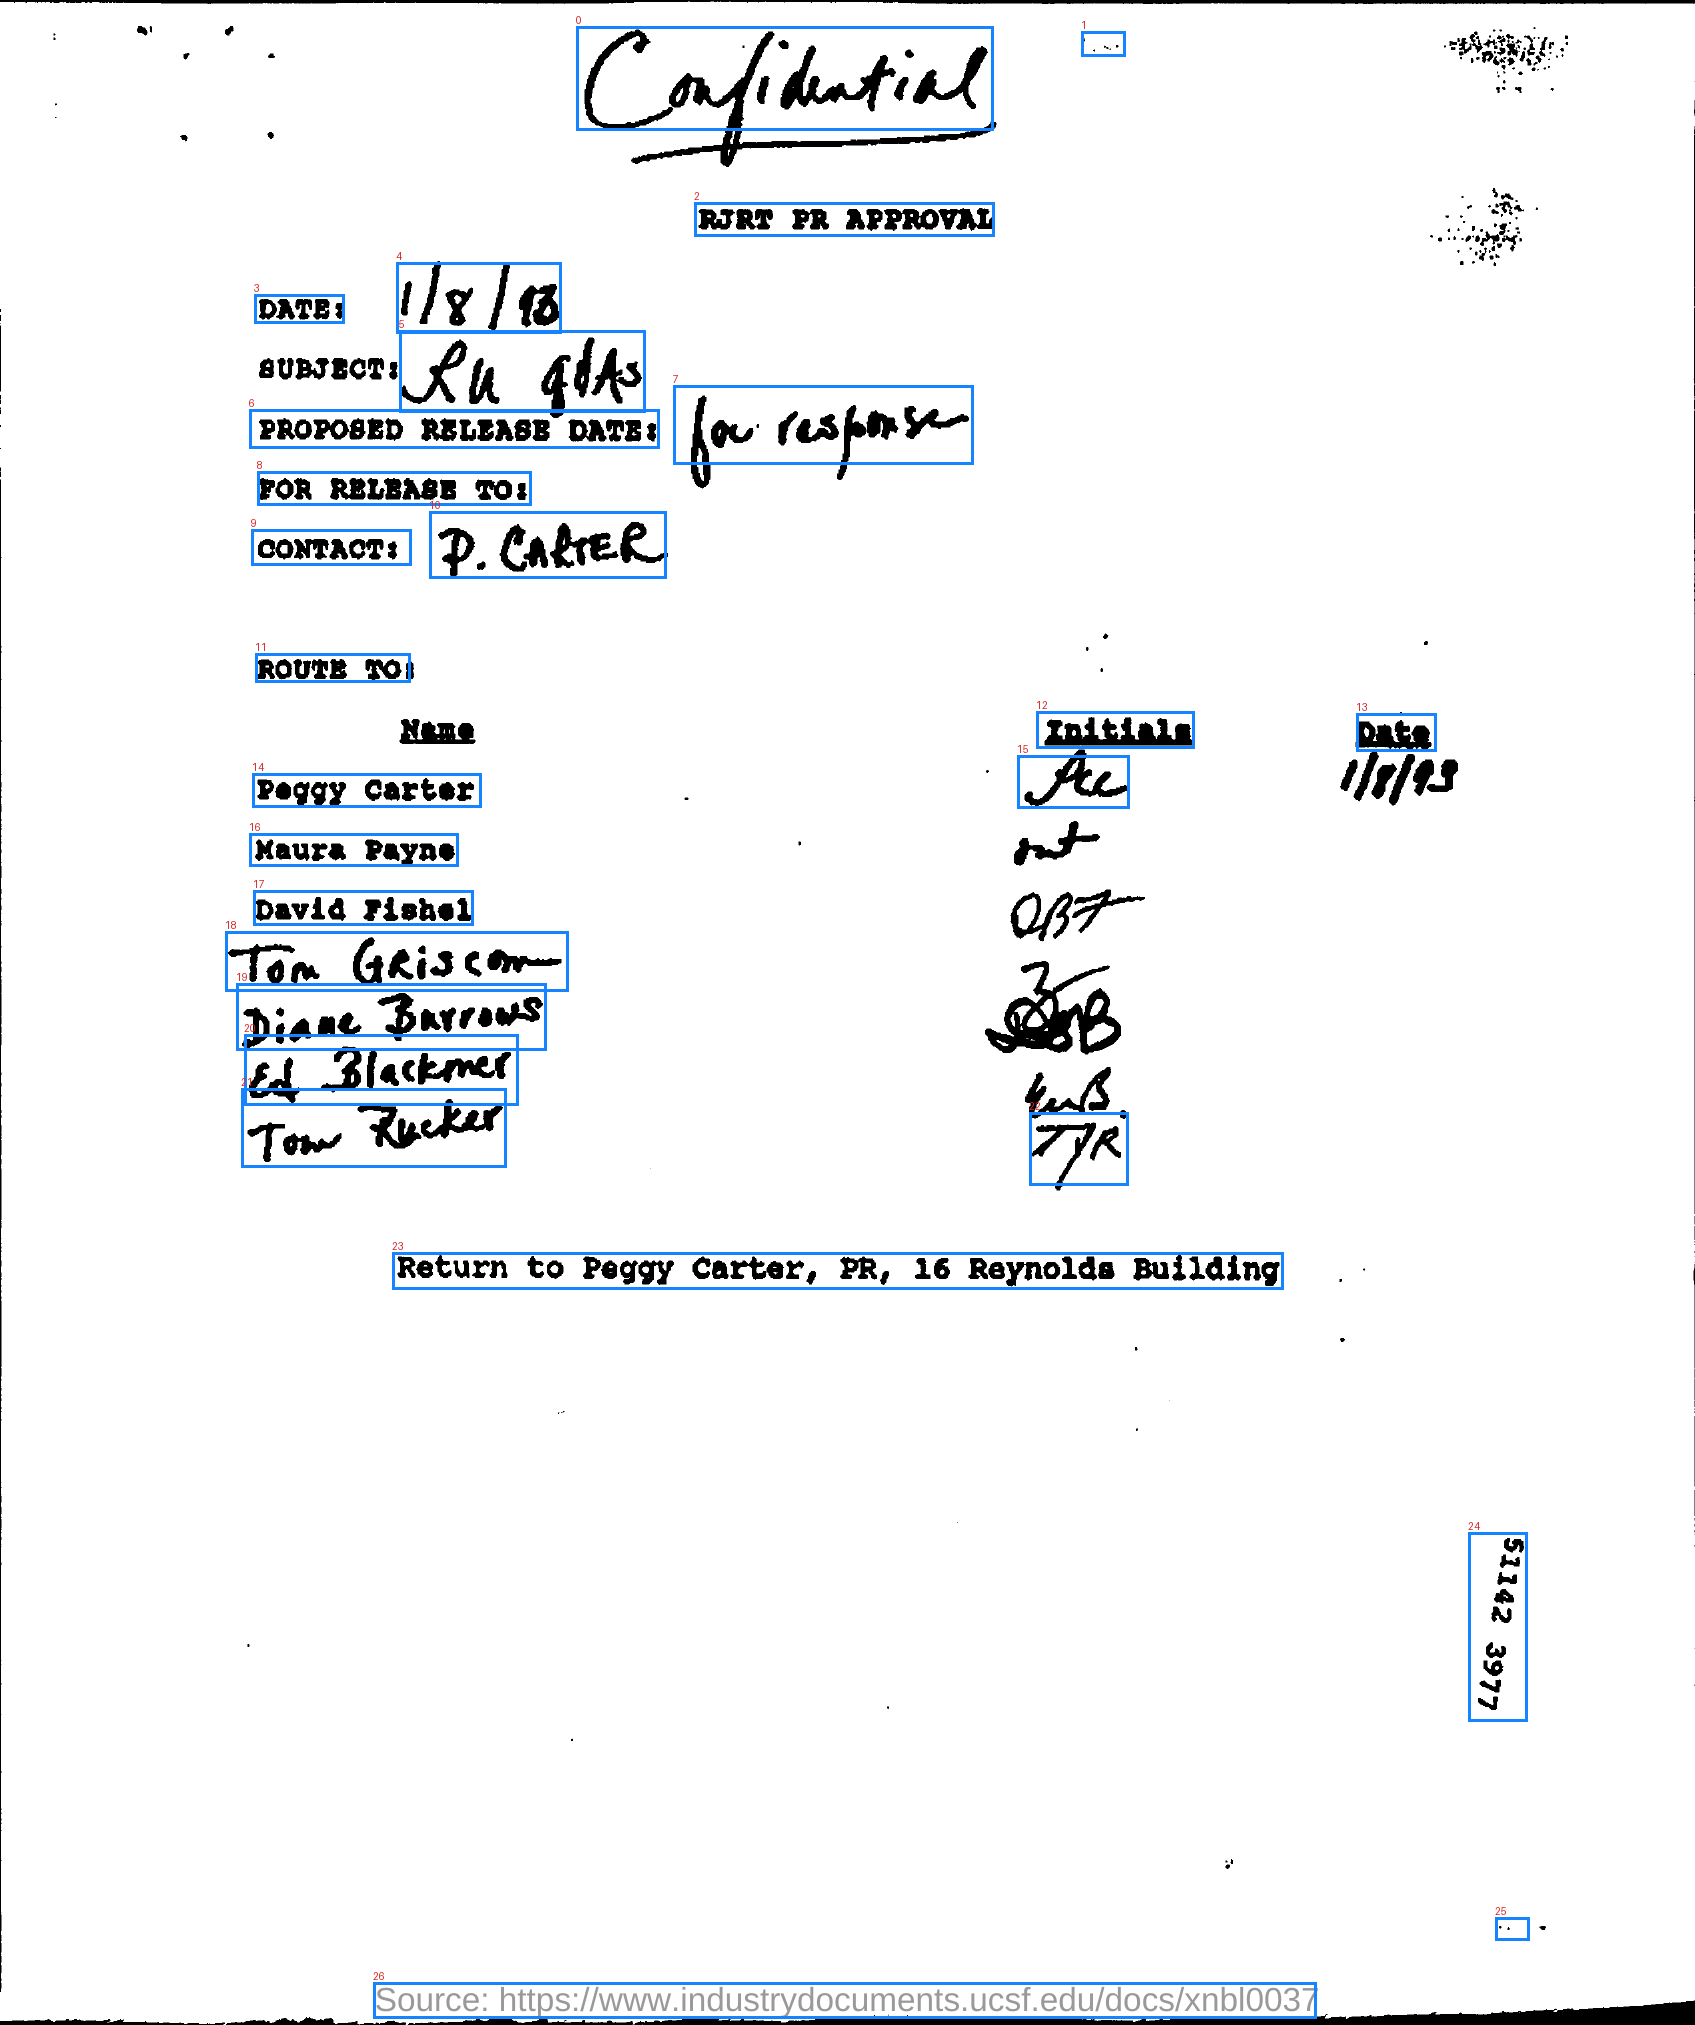

,text,bbox
0,Confidential,"[576.0, 26.0, 993.0, 130.0]"
1,.. ..,"[1081.0, 31.0, 1125.0, 56.0]"
2,RJRT PR APPROVAL,"[694.0, 202.0, 994.0, 236.0]"
3,DATE :,"[254.0, 294.0, 344.0, 323.0]"
4,1/8/13,"[396.0, 262.0, 561.0, 333.0]"
5,Ru alAs,"[399.0, 330.0, 645.0, 412.0]"
6,PROPOSED RELEASE DATE:,"[249.0, 409.0, 659.0, 448.0]"
7,for response,"[673.0, 385.0, 973.0, 464.0]"
8,FOR RELEASE TO:,"[257.0, 471.0, 531.0, 505.0]"
9,CONTACT:,"[251.0, 529.0, 411.0, 565.0]"


In [4]:
sample_spans = ocr_spans(DATASET, sample, EXTERNAL_ROOT, EXTERNAL_ROOT / "model_matrix_cache/ocr")[:32]
image = Image.open(sample["image_path"]).convert("RGB")
overlay = image.copy()
draw = ImageDraw.Draw(overlay)
for index, span in enumerate(sample_spans):
    box = [float(value) for value in span["bbox"]]
    draw.rectangle(box, outline="#1683ff", width=3)
    draw.text((box[0], max(0, box[1] - 12)), str(index), fill="#d62728")
display(overlay)
display(pd.DataFrame(sample_spans))


## Feature Processing

In [5]:
TEXT_DIM = 384
NODE_DIM = TEXT_DIM + 10
GRAPH_MODELS = {
    "gatv2_knn",
    "graph_transformer",
    "sam2_graph_transformer",
    "hybrid_gatv2_knn",
    "graphcolbert",
    "graphcolbert_film",
    "ocr_reasoner",
    "epoch_view_graph_transformer",
    "sam2_graph_nodes",
}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_torch(path: Path) -> Any:
    kwargs = {"map_location": "cpu"}
    if "weights_only" in inspect.signature(torch.load).parameters:
        kwargs["weights_only"] = False
    return torch.load(path, **kwargs)


def write_jsonl(rows: list[dict[str, Any]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("".join(json.dumps(row, ensure_ascii=False) + "\n" for row in rows), encoding="utf-8")


def knn_edges(x: torch.Tensor, k: int = 5) -> torch.Tensor:
    if len(x) <= 1:
        return torch.zeros((2, 1), dtype=torch.long)
    centers = x[:, TEXT_DIM : TEXT_DIM + 2]
    distances = torch.cdist(centers, centers)
    distances.fill_diagonal_(float("inf"))
    k_eff = min(k, len(x) - 1)
    dst = distances.topk(k_eff, largest=False).indices.reshape(-1)
    src = torch.arange(len(x)).repeat_interleave(k_eff)
    return torch.stack([torch.cat([src, dst]), torch.cat([dst, src])])


class RowDataset(Dataset):
    def __init__(self, rows: list[dict[str, Any]]) -> None:
        self.rows = rows

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, index: int) -> dict[str, Any]:
        return self.rows[index]


class MatrixFeatureStore:
    def __init__(self, dataset: str, model_name: str, cache_root: Path, device: torch.device) -> None:
        self.dataset = dataset
        self.model_name = model_name
        self.cache_root = cache_root
        self.cache_root.mkdir(parents=True, exist_ok=True)
        self.device = device
        self.text_encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=str(device))
        self._question: dict[str, torch.Tensor] = {}
        self._question_tokens: dict[str, torch.Tensor] = {}
        self._text_values: dict[str, torch.Tensor] = {}
        self._graphs: dict[str, Data] = {}
        self._sam_model = None

    def encode_texts(self, values: list[str]) -> torch.Tensor:
        if not values:
            return torch.zeros((0, TEXT_DIM), dtype=torch.float32)
        # Keep the tensors required by this call separately from the bounded
        # cache.  A large OCR candidate set can evict an earlier requested
        # value while the same call is still being assembled (for example the
        # valid AI2D option "-").  In that case the cache must not make a
        # batch fail with KeyError.
        unique_values = list(dict.fromkeys(str(value) for value in values))
        resolved = {value: self._text_values[value] for value in unique_values if value in self._text_values}
        missing = [value for value in unique_values if value not in resolved]
        if missing:
            encoded = self.text_encoder.encode(missing, batch_size=128, convert_to_tensor=True, normalize_embeddings=False)
            for value, tensor in zip(missing, encoded.detach().cpu().float()):
                resolved[value] = tensor
                self._text_values[value] = tensor
                if len(self._text_values) > 50_000:
                    self._text_values.pop(next(iter(self._text_values)))
        return torch.stack([resolved[str(value)] for value in values])

    def question(self, row: dict[str, Any]) -> torch.Tensor:
        key = row["sample_id"]
        if key not in self._question:
            self._question[key] = self.encode_texts([str(row["question"])])[0]
        return self._question[key]

    def question_tokens(self, row: dict[str, Any]) -> torch.Tensor:
        key = row["sample_id"]
        if key not in self._question_tokens:
            tokens = [token for token in str(row["question"]).split() if token][:32] or [""]
            self._question_tokens[key] = self.encode_texts(tokens)
        return self._question_tokens[key]

    def questions(self, rows: list[dict[str, Any]]) -> torch.Tensor:
        missing = [row for row in rows if row["sample_id"] not in self._question]
        if missing:
            encoded = self.text_encoder.encode(
                [str(row["question"]) for row in missing],
                batch_size=128,
                convert_to_tensor=True,
                normalize_embeddings=False,
            ).detach().cpu().float()
            for row, tensor in zip(missing, encoded):
                self._question[row["sample_id"]] = tensor
        return torch.stack([self._question[row["sample_id"]] for row in rows])

    def question_tokens_batch(self, rows: list[dict[str, Any]]) -> list[torch.Tensor]:
        missing = [row for row in rows if row["sample_id"] not in self._question_tokens]
        if missing:
            token_rows = [[token for token in str(row["question"]).split() if token][:32] or [""] for row in missing]
            lengths = [len(tokens) for tokens in token_rows]
            encoded = self.encode_texts([token for tokens in token_rows for token in tokens])
            offset = 0
            for row, length in zip(missing, lengths):
                self._question_tokens[row["sample_id"]] = encoded[offset : offset + length]
                offset += length
        return [self._question_tokens[row["sample_id"]] for row in rows]

    def prewarm_questions(self, rows: list[dict[str, Any]], chunk_size: int = 1024) -> None:
        cache_dir = self.cache_root / "question_embeddings"
        cache_path = cache_dir / f"{self.dataset}_minilm_l6_v2_v1.pt"
        requested_ids = {row["sample_id"] for row in rows}
        if cache_path.exists():
            payload = load_torch(cache_path)
            self._question.update({key: value for key, value in payload.get("questions", {}).items() if key in requested_ids})
            self._question_tokens.update({key: value for key, value in payload.get("question_tokens", {}).items() if key in requested_ids})
        before = (len(self._question), len(self._question_tokens))
        for start in tqdm(range(0, len(rows), chunk_size), desc="MiniLM text cache", leave=False):
            chunk = rows[start : start + chunk_size]
            self.questions(chunk)
            self.question_tokens_batch(chunk)
        after = (len(self._question), len(self._question_tokens))
        if after != before or not cache_path.exists():
            cache_dir.mkdir(parents=True, exist_ok=True)
            temp_path = cache_path.with_suffix(".tmp")
            torch.save({"questions": self._question, "question_tokens": self._question_tokens}, temp_path)
            temp_path.replace(cache_path)

    def _sam_boxes(self, row: dict[str, Any], width: int, height: int) -> list[list[float]]:
        cache_dir = self.cache_root / "sam2_boxes"
        cache_dir.mkdir(parents=True, exist_ok=True)
        path = cache_dir / f"{row['image_id']}.json"
        if path.exists():
            return json.loads(path.read_text(encoding="utf-8"))
        try:
            from ultralytics import SAM

            if self._sam_model is None:
                self._sam_model = SAM(str(EXTERNAL_ROOT / "models/sam2/sam2.1_b.pt"))
            result = self._sam_model(str(row["image_path"]), imgsz=768, verbose=False)[0]
            boxes = result.boxes.xyxy.detach().cpu().tolist()[:80] if result.boxes is not None else []
        except Exception as exc:
            print(f"[SAM2 fallback] {type(exc).__name__}: {exc}", flush=True)
            boxes = [[0.0, 0.0, float(width), float(height)]]
        path.write_text(json.dumps(boxes), encoding="utf-8")
        return boxes

    def graph(self, row: dict[str, Any]) -> Data:
        key = row["image_id"]
        if key in self._graphs:
            graph = self._graphs.pop(key)
            self._graphs[key] = graph
            return graph
        directory = self.cache_root / "graphs" / self.dataset / self.model_name
        directory.mkdir(parents=True, exist_ok=True)
        path = directory / f"{key}.pt"
        if path.exists():
            graph = load_torch(path)
            self._graphs[key] = graph
            if len(self._graphs) > 8192:
                self._graphs.pop(next(iter(self._graphs)))
            return graph

        spans = ocr_spans(self.dataset, row, EXTERNAL_ROOT, self.cache_root / "ocr")
        width, height = Image.open(row["image_path"]).size
        texts = [str(span["text"]) for span in spans[:80]]
        text_embeddings = self.encode_texts(texts)
        features = []
        for index, span in enumerate(spans[:80]):
            x1, y1, x2, y2 = [float(value) for value in span.get("bbox", [0, 0, 0, 0])]
            geometry = torch.tensor([
                (x1 + x2) / 2 / max(1, width), (y1 + y2) / 2 / max(1, height),
                max(1.0, x2 - x1) / max(1, width), max(1.0, y2 - y1) / max(1, height),
                max(1.0, (x2 - x1) * (y2 - y1)) / max(1, width * height),
                x1 / max(1, width), y1 / max(1, height), x2 / max(1, width), y2 / max(1, height), 1.0,
            ])
            features.append(torch.cat([text_embeddings[index], geometry]))
        if self.model_name in {"sam2_graph_nodes", "sam2_graph_transformer"}:
            for x1, y1, x2, y2 in self._sam_boxes(row, width, height):
                geometry = torch.tensor([
                    (x1 + x2) / 2 / max(1, width), (y1 + y2) / 2 / max(1, height),
                    max(1.0, x2 - x1) / max(1, width), max(1.0, y2 - y1) / max(1, height),
                    max(1.0, (x2 - x1) * (y2 - y1)) / max(1, width * height),
                    x1 / max(1, width), y1 / max(1, height), x2 / max(1, width), y2 / max(1, height), 0.0,
                ])
                features.append(torch.cat([torch.zeros(TEXT_DIM), geometry]))
        if not features:
            features = [torch.zeros(NODE_DIM)]
            texts = [""]
        x = torch.stack(features).float()
        candidates = candidate_texts([{"text": value} for value in texts], max_candidates=128) or [""]
        candidate_embeddings = self.encode_texts(candidates)
        graph = Data(x=x, edge_index=knn_edges(x), candidate_embeddings=candidate_embeddings)
        graph.candidate_texts = candidates
        torch.save(graph, path)
        self._graphs[key] = graph
        if len(self._graphs) > 8192:
            self._graphs.pop(next(iter(self._graphs)))
        return graph

    def candidates(self, row: dict[str, Any], graph: Data) -> tuple[list[str], torch.Tensor, int]:
        if self.dataset == "ai2d":
            values = [str(value) for value in row.get("options", [])]
            embeddings = self.encode_texts(values)
            target = int(row.get("correct_option_idx", 0))
            return values, embeddings, target
        values = list(graph.candidate_texts)
        embeddings = graph.candidate_embeddings.float()
        answers = row.get("answers", [])
        scores = [max((anls_score(value, [answer]) for answer in answers), default=0.0) for value in values]
        target = int(np.argmax(scores)) if scores else 0
        return values, embeddings, target




## Architecture

In [6]:
class GraphColbertFilmModel(nn.Module):
    def __init__(self, hidden: int = 192, out_dim: int = 192) -> None:
        super().__init__()
        self.model_name = 'graphcolbert_film'
        self.input = nn.Linear(NODE_DIM, hidden)
        self.q_proj = nn.Sequential(nn.Linear(TEXT_DIM, hidden), nn.GELU(), nn.Linear(hidden, out_dim))
        self.candidate_proj = nn.Sequential(nn.Linear(TEXT_DIM, hidden), nn.GELU(), nn.Linear(hidden, out_dim))
        if self.model_name == "ocr_reasoner":
            self.layer1 = nn.Linear(hidden, hidden)
            self.layer2 = nn.Linear(hidden, hidden)
        elif self.model_name in {"graph_transformer", "epoch_view_graph_transformer", "sam2_graph_transformer"}:
            self.layer1 = TransformerConv(hidden, hidden // 4, heads=4, dropout=0.1)
            self.layer2 = TransformerConv(hidden, hidden // 4, heads=4, dropout=0.1)
        else:
            self.layer1 = GATv2Conv(hidden, hidden // 4, heads=4, dropout=0.1)
            self.layer2 = GATv2Conv(hidden, hidden // 4, heads=4, dropout=0.1)
        self.node_out = nn.Linear(hidden, out_dim)
        gate = nn.Sequential(nn.Linear(out_dim, out_dim // 2), nn.GELU(), nn.Linear(out_dim // 2, 1))
        self.pool = GlobalAttention(gate_nn=gate)
        self.hybrid = nn.Sequential(nn.Linear(out_dim * 2, out_dim), nn.GELU(), nn.Linear(out_dim, out_dim))
        self.film = nn.Linear(out_dim, out_dim * 2)
        self.epoch_view = nn.Sequential(nn.Linear(out_dim, out_dim), nn.GELU(), nn.Linear(out_dim, out_dim))

    def encode_nodes(self, batch: Batch) -> torch.Tensor:
        x = F.gelu(self.input(batch.x))
        if self.model_name == "ocr_reasoner":
            x = F.gelu(self.layer1(x))
            x = F.gelu(self.layer2(x))
        else:
            x = F.gelu(self.layer1(x, batch.edge_index))
            x = F.gelu(self.layer2(x, batch.edge_index))
        nodes = F.gelu(self.node_out(x))
        if self.model_name == "epoch_view_graph_transformer":
            nodes = nodes + self.epoch_view(nodes)
        return nodes

    def encode(self, batch: Batch, questions: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor]:
        nodes = self.encode_nodes(batch)
        if self.model_name == "graphcolbert_film" and questions is not None:
            q = self.q_proj(questions)
            gamma, beta = self.film(q).chunk(2, dim=-1)
            nodes = nodes * (1 + gamma[batch.batch]) + beta[batch.batch]
        pooled = self.pool(nodes, batch.batch)
        return F.normalize(pooled, dim=-1), nodes

    def retrieval_logits(self, batch: Batch, questions: torch.Tensor, question_tokens: list[torch.Tensor] | None = None) -> torch.Tensor:
        q = F.normalize(self.q_proj(questions), dim=-1)
        docs, nodes = self.encode(batch)
        if self.model_name not in {"graphcolbert", "graphcolbert_film"}:
            return q @ docs.T
        token_queries = [self.q_proj(tokens.to(q.device)) for tokens in (question_tokens or [])]
        max_tokens = max(tokens.shape[0] for tokens in token_queries)
        token_dense = torch.zeros((len(token_queries), max_tokens, token_queries[0].shape[-1]), device=q.device)
        token_mask = torch.zeros((len(token_queries), max_tokens), dtype=torch.bool, device=q.device)
        for index, tokens in enumerate(token_queries):
            token_dense[index, : tokens.shape[0]] = F.normalize(tokens, dim=-1)
            token_mask[index, : tokens.shape[0]] = True
        node_dense, node_mask = to_dense_batch(nodes, batch.batch)
        if self.model_name == "graphcolbert_film":
            gamma, beta = self.film(q).chunk(2, dim=-1)
            conditioned = node_dense.unsqueeze(0) * (1 + gamma[:, None, None, :]) + beta[:, None, None, :]
            conditioned = F.normalize(conditioned, dim=-1)
            scores = torch.einsum("itd,ijnd->ijtn", token_dense, conditioned)
        else:
            node_dense = F.normalize(node_dense, dim=-1)
            scores = torch.einsum("itd,jnd->ijtn", token_dense, node_dense)
        scores = scores.masked_fill(~node_mask[None, :, None, :], -torch.inf)
        token_scores = scores.max(dim=-1).values.masked_fill(~token_mask[:, None, :], 0.0)
        return token_scores.sum(dim=-1) / token_mask.sum(dim=-1).clamp_min(1)[:, None]

    def vqa_logits(self, graph: Data, question: torch.Tensor, candidates: torch.Tensor) -> torch.Tensor:
        batch = Batch.from_data_list([graph]).to(question.device)
        q = F.normalize(self.q_proj(question.unsqueeze(0)), dim=-1)
        doc, nodes = self.encode(batch, question.unsqueeze(0) if self.model_name == "graphcolbert_film" else None)
        if self.model_name in {"hybrid_gatv2_knn", "graphcolbert", "graphcolbert_film"}:
            if self.model_name.startswith("graphcolbert"):
                node_context = F.normalize(nodes, dim=-1)
                context = F.normalize((q @ node_context.T).softmax(dim=1) @ node_context + q, dim=-1)
            else:
                context = F.normalize(self.hybrid(torch.cat([doc, q], dim=-1)), dim=-1)
        else:
            context = F.normalize(doc + q, dim=-1)
        candidate = F.normalize(self.candidate_proj(candidates.to(question.device)), dim=-1)
        return (context @ candidate.T).squeeze(0)

    def vqa_logits_batch(
        self,
        batch: Batch,
        questions: torch.Tensor,
        candidates: list[torch.Tensor],
    ) -> list[torch.Tensor]:
        q = F.normalize(self.q_proj(questions), dim=-1)
        docs, nodes = self.encode(batch, questions if self.model_name == "graphcolbert_film" else None)
        contexts: list[torch.Tensor] = []
        for index in range(int(batch.num_graphs)):
            if self.model_name.startswith("graphcolbert"):
                current_nodes = F.normalize(nodes[batch.batch == index], dim=-1)
                context = F.normalize((q[index : index + 1] @ current_nodes.T).softmax(dim=1) @ current_nodes + q[index : index + 1], dim=-1)
            elif self.model_name == "hybrid_gatv2_knn":
                context = F.normalize(self.hybrid(torch.cat([docs[index : index + 1], q[index : index + 1]], dim=-1)), dim=-1)
            else:
                context = F.normalize(docs[index : index + 1] + q[index : index + 1], dim=-1)
            contexts.append(context)
        return [
            (context @ F.normalize(self.candidate_proj(values.to(questions.device)), dim=-1).T).squeeze(0)
            for context, values in zip(contexts, candidates)
        ]




In [7]:
architecture = {
    "name": MODEL_TITLE,
    "backend": MODEL_NAME,
    "description": 'GATv2 graph encoder, token-node late interaction and question-conditioned FiLM.',
    "node_features": "MiniLM OCR text embedding + normalized bounding-box geometry",
    "edges": "KNN in learned node-feature space",
    "validation": "after every epoch; best composite checkpoint",
}
display(architecture)
model_preview = GraphColbertFilmModel()
print(model_preview)
print("trainable parameters:", sum(parameter.numel() for parameter in model_preview.parameters()))
del model_preview


{'name': 'GraphColBERT + FiLM',
 'backend': 'graphcolbert_film',
 'description': 'GATv2 graph encoder, token-node late interaction and question-conditioned FiLM.',
 'node_features': 'MiniLM OCR text embedding + normalized bounding-box geometry',
 'edges': 'KNN in learned node-feature space',
 'validation': 'after every epoch; best composite checkpoint'}

GraphColbertFilmModel(
  (input): Linear(in_features=394, out_features=192, bias=True)
  (q_proj): Sequential(
    (0): Linear(in_features=384, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=192, out_features=192, bias=True)
  )
  (candidate_proj): Sequential(
    (0): Linear(in_features=384, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=192, out_features=192, bias=True)
  )
  (layer1): GATv2Conv(192, 48, heads=4)
  (layer2): GATv2Conv(192, 48, heads=4)
  (node_out): Linear(in_features=192, out_features=192, bias=True)
  (pool): GlobalAttention(gate_nn=Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=96, out_features=1, bias=True)
  ), nn=None)
  (hybrid): Sequential(
    (0): Linear(in_features=384, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=192, out_features=192, b

C:\Users\Jet\AppData\Local\Temp\ipykernel_21376\3627789443.py:19: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate)


## Training And Validation

In [8]:
def multipositive_loss(logits: torch.Tensor, image_ids: list[str]) -> torch.Tensor:
    positive = torch.tensor([[left == right for right in image_ids] for left in image_ids], device=logits.device)
    numerator = torch.logsumexp(logits.masked_fill(~positive, -torch.inf) / 0.07, dim=1)
    denominator = torch.logsumexp(logits / 0.07, dim=1)
    reverse_num = torch.logsumexp(logits.T.masked_fill(~positive.T, -torch.inf) / 0.07, dim=1)
    reverse_den = torch.logsumexp(logits.T / 0.07, dim=1)
    return -0.5 * ((numerator - denominator).mean() + (reverse_num - reverse_den).mean())


def collate(rows: list[dict[str, Any]], store: MatrixFeatureStore) -> dict[str, Any]:
    return {
        "rows": rows,
        "graphs": [store.graph(row) for row in rows],
        "questions": store.questions(rows),
        "question_tokens": store.question_tokens_batch(rows),
        "image_ids": [row["image_id"] for row in rows],
    }


@torch.no_grad()
def validation_loss(
    model: GraphMatrixModel,
    rows: list[dict[str, Any]],
    store: MatrixFeatureStore,
    device: torch.device,
    batch_size: int,
) -> float:
    model.eval()
    loader = DataLoader(RowDataset(rows), batch_size=batch_size, shuffle=False, collate_fn=lambda values: collate(values, store))
    losses: list[float] = []
    for payload in tqdm(loader, desc="validation loss", leave=False, disable=os.environ.get("DISABLE_TQDM") == "1"):
        graphs = Batch.from_data_list(payload["graphs"]).to(device)
        questions = payload["questions"].to(device)
        retrieval = multipositive_loss(model.retrieval_logits(graphs, questions, payload["question_tokens"]), payload["image_ids"])
        candidate_rows = [store.candidates(row, graph) for row, graph in zip(payload["rows"], payload["graphs"])]
        logits_rows = model.vqa_logits_batch(graphs, questions, [values for _, values, _ in candidate_rows])
        answer_losses = [
            F.cross_entropy(logits.unsqueeze(0), torch.tensor([target], device=device))
            for logits, (_, _, target) in zip(logits_rows, candidate_rows)
        ]
        losses.append(float(0.5 * retrieval + 0.5 * torch.stack(answer_losses).mean()))
    return float(np.mean(losses)) if losses else 0.0


@torch.no_grad()
def evaluate(model: GraphMatrixModel, rows: list[dict[str, Any]], store: MatrixFeatureStore, device: torch.device, batch_size: int) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    model.eval()
    unique_docs: dict[str, dict[str, Any]] = {}
    for row in rows:
        unique_docs.setdefault(row["image_id"], row)
    docs = list(unique_docs.values())
    doc_graphs = [store.graph(row) for row in docs]
    questions = store.questions(rows).to(device)
    q = F.normalize(model.q_proj(questions), dim=-1)
    similarities = []
    for start in range(0, len(doc_graphs), batch_size):
        batch = Batch.from_data_list(doc_graphs[start : start + batch_size]).to(device)
        doc_emb, _nodes = model.encode(batch)
        # Full validation uses pooled document embeddings. The late-interaction
        # objective remains active during training, while this avoids an
        # impractical O(questions * documents * nodes) Python loop.
        similarities.append((q @ doc_emb.T).cpu())
    similarity = torch.cat(similarities, dim=1).numpy()
    retrieval = retrieval_metrics(similarity, [row["image_id"] for row in rows], [row["image_id"] for row in docs])

    predictions = []
    loader = DataLoader(RowDataset(rows), batch_size=batch_size, shuffle=False, collate_fn=lambda values: collate(values, store))
    for payload in tqdm(loader, desc="VQA evaluation", disable=os.environ.get("DISABLE_TQDM") == "1"):
        graphs = Batch.from_data_list(payload["graphs"]).to(device)
        questions = payload["questions"].to(device)
        candidate_rows = [store.candidates(row, graph) for row, graph in zip(payload["rows"], payload["graphs"])]
        logits_rows = model.vqa_logits_batch(graphs, questions, [values for _, values, _ in candidate_rows])
        for row, logits, (values, _, _) in zip(payload["rows"], logits_rows, candidate_rows):
            prediction = values[int(logits.argmax())] if values else ""
            predictions.append(vqa_row(store.dataset, row, prediction))
    labeled = [row for row in predictions if row.get("gold_answers")]
    score = float(np.mean([row["score"] for row in labeled])) if labeled else None
    exact = float(np.mean([row["exact"] for row in labeled])) if labeled else None
    return {"retrieval": retrieval, "vqa": {"metric": "accuracy" if store.dataset == "ai2d" else "anls",
            "score": score, "exact_accuracy": exact, "labels_available": bool(labeled)}}, predictions


def main() -> None:
    parser = argparse.ArgumentParser(description="Train local models in the controlled 11x3 matrix.")
    parser.add_argument("--dataset", choices=DATASETS, required=True)
    parser.add_argument("--model", choices=TRAINABLE_LOCAL_MODELS, required=True)
    parser.add_argument("--split", choices=["val", "test"], default="val")
    parser.add_argument("--seed", type=int, choices=SEEDS, default=42)
    parser.add_argument("--max-samples", type=int, default=None)
    parser.add_argument("--output-dir", type=Path, default=ROOT / "runs/model_matrix")
    parser.add_argument("--resume", action=argparse.BooleanOptionalAction, default=True)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--early-stopping-patience", type=int, default=5)
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--eval-batch-size", type=int, default=32)
    args = parser.parse_args()
    run_local_experiment_config(args)


def run_local_experiment_config(args: argparse.Namespace) -> dict[str, Any]:
    if args.model in {"clip", "siglip"}:
        raise NotImplementedError("Frozen CLIP/SigLIP feature runner is provided by train_model_matrix_vision.py")

    run_dir = Path(args.run_dir_override) if getattr(args, "run_dir_override", None) else args.output_dir / args.dataset / args.model / f"seed{args.seed}" / args.split
    ensure_free_space(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "config.json").write_text(json.dumps({
        "dataset": args.dataset, "model": args.model, "split": args.split, "seed": args.seed,
        "max_samples": args.max_samples, "epochs": args.epochs, "early_stopping_patience": args.early_stopping_patience,
        "batch_size": args.batch_size, "eval_batch_size": args.eval_batch_size,
        "checkpoint_selection": "0.5*vqa+0.5*mean_r1", "resume": args.resume,
    }, ensure_ascii=False, indent=2), encoding="utf-8")
    metrics_path = run_dir / "metrics.json"
    if args.resume and metrics_path.exists():
        existing = json.loads(metrics_path.read_text(encoding="utf-8"))
        test_path = run_dir / "test/metrics.json" if getattr(args, "run_dir_override", None) else run_dir.parent / "test/metrics.json"
        test_ready = args.split == "test" or test_path.exists()
        if existing.get("status") == "completed_full" and existing.get("epochs_completed") == args.epochs and test_ready:
            print({"resume": "completed checkpoint", "status": existing.get("status"), "epochs": existing.get("epochs_completed")})
            return existing

    seed_everything(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    rows = load_rows(args.dataset, EXTERNAL_ROOT)
    train_rows = split_rows(rows, "train", args.max_samples)
    eval_rows = split_rows(rows, args.split, args.max_samples)
    store = MatrixFeatureStore(args.dataset, args.model, EXTERNAL_ROOT / "model_matrix_cache", device)
    store.prewarm_questions(train_rows + eval_rows)
    model = GraphColbertFilmModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
    loader = DataLoader(RowDataset(train_rows), batch_size=args.batch_size, shuffle=True, collate_fn=lambda values: collate(values, store))
    history_path = run_dir / "history.json"
    last_checkpoint_path = run_dir / "checkpoint_last.pt"
    history = []
    best_composite = -math.inf
    started = time.perf_counter()

    start_epoch = 1
    if args.resume and history_path.exists() and last_checkpoint_path.exists():
        history = json.loads(history_path.read_text(encoding="utf-8"))
        last = load_torch(last_checkpoint_path)
        model.load_state_dict(last["model"])
        optimizer.load_state_dict(last["optimizer"])
        start_epoch = int(last["epoch"]) + 1
        if history:
            best_composite = max(float(row["composite"]) for row in history)

    epochs = min(args.epochs, 2) if args.max_samples is not None else args.epochs
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        total_loss = 0.0
        steps = 0
        for payload in tqdm(loader, desc=f"{args.dataset}/{args.model}/seed{args.seed} epoch {epoch}/{epochs}", disable=os.environ.get("DISABLE_TQDM") == "1"):
            graphs = Batch.from_data_list(payload["graphs"]).to(device)
            questions = payload["questions"].to(device)
            retrieval_logits = model.retrieval_logits(graphs, questions, payload["question_tokens"])
            retrieval_loss = multipositive_loss(retrieval_logits, payload["image_ids"])
            candidate_rows = [store.candidates(row, graph) for row, graph in zip(payload["rows"], payload["graphs"])]
            logits_rows = model.vqa_logits_batch(graphs, questions, [values for _, values, _ in candidate_rows])
            vqa_losses = [
                F.cross_entropy(logits.unsqueeze(0), torch.tensor([target], device=device))
                for logits, (_, _, target) in zip(logits_rows, candidate_rows)
            ]
            vqa_loss = torch.stack(vqa_losses).mean()
            loss = 0.5 * retrieval_loss + 0.5 * vqa_loss
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += float(loss.detach())
            steps += 1
        evaluation, _ = evaluate(model, eval_rows, store, device, args.eval_batch_size)
        val_loss = validation_loss(model, eval_rows, store, device, args.eval_batch_size)
        mean_r1 = float(evaluation["retrieval"]["mean_recall_at_k"]["1"])
        vqa_score = float(evaluation["vqa"]["score"])
        composite = 0.5 * mean_r1 + 0.5 * vqa_score
        history.append({"epoch": epoch, "loss": total_loss / max(1, steps), "val_loss": val_loss, "composite": composite, **evaluation})
        run_dir.mkdir(parents=True, exist_ok=True)
        history_path.write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding="utf-8")
        if composite > best_composite:
            best_composite = composite
            torch.save({"model": model.state_dict(), "epoch": epoch, "composite": composite}, run_dir / "checkpoint_best.pt")
        torch.save(
            {"model": model.state_dict(), "optimizer": optimizer.state_dict(), "epoch": epoch},
            last_checkpoint_path,
        )

    best = load_torch(run_dir / "checkpoint_best.pt")
    model.load_state_dict(best["model"])
    evaluation, predictions = evaluate(model, eval_rows, store, device, args.eval_batch_size)
    elapsed = time.perf_counter() - started
    metrics = {
        "dataset": args.dataset,
        "model": args.model,
        "split": args.split,
        "seed": args.seed,
        "status": "completed_full" if args.max_samples is None and len(history) == args.epochs else "completed_smoke",
        "num_samples": len(eval_rows),
        "epochs_completed": len(history),
        "best_epoch": int(best["epoch"]),
        "best_composite": float(best["composite"]),
        "history": history,
        "training_execution": {"mode": "full", "full_training_was_run": True},
        **evaluation,
        "resources": {
            "wall_time_seconds": elapsed,
            "latency_ms_per_question": elapsed * 1000 / max(1, len(eval_rows)),
            "throughput_questions_per_second": len(eval_rows) / elapsed if elapsed else None,
            "peak_ram_mb": psutil.Process().memory_info().rss / (1024 * 1024),
            "peak_vram_mb": torch.cuda.max_memory_allocated() / (1024 * 1024) if torch.cuda.is_available() else 0.0,
            "parameter_count": sum(parameter.numel() for parameter in model.parameters()),
        },
        "config": vars(args) | {"output_dir": str(args.output_dir)},
    }
    write_jsonl(predictions, run_dir / "predictions.jsonl")
    metrics_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    if args.split == "val":
        test_rows = split_rows(rows, "test", args.max_samples)
        store.prewarm_questions(test_rows)
        test_evaluation, test_predictions = evaluate(model, test_rows, store, device, args.eval_batch_size)
        test_dir = run_dir / "test" if getattr(args, "run_dir_override", None) else run_dir.parent / "test"
        test_dir.mkdir(parents=True, exist_ok=True)
        test_metrics = {
            "dataset": args.dataset, "model": args.model, "split": "test", "seed": args.seed,
            "status": "completed_full" if args.max_samples is None else "completed_smoke",
            "num_samples": len(test_rows), **test_evaluation,
        }
        metrics["test"] = test_metrics
        write_jsonl(test_predictions, test_dir / "predictions.jsonl")
        (test_dir / "metrics.json").write_text(json.dumps(test_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
        if args.dataset != "ai2d":
            submission = [{"questionId": row["question_id"], "answer": row["pred_answer"]} for row in test_predictions]
            (test_dir / "submission.json").write_text(json.dumps(submission, ensure_ascii=False, indent=2), encoding="utf-8")
        metrics_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    print({"status": metrics["status"], "best_epoch": metrics["best_epoch"], "epochs": metrics["epochs_completed"]})
    return metrics


def train_local_experiment(
    *,
    dataset: str,
    model: str,
    run_dir: Path,
    epochs: int = 40,
    seed: int = 42,
    batch_size: int = 8,
    eval_batch_size: int = 16,
    max_samples: int | None = None,
    resume: bool = True,
) -> dict[str, Any]:
    args = argparse.Namespace(
        dataset=dataset,
        model=model,
        split="val",
        seed=seed,
        max_samples=max_samples,
        output_dir=run_dir.parent,
        run_dir_override=run_dir,
        resume=resume,
        epochs=epochs,
        early_stopping_patience=0,
        batch_size=batch_size,
        eval_batch_size=eval_batch_size,
    )
    return run_local_experiment_config(args)


In [9]:
metrics = train_local_experiment(
    dataset=DATASET,
    model=MODEL_NAME,
    run_dir=RUN_DIR,
    epochs=EPOCHS,
    seed=SEED,
    batch_size=BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    max_samples=None,
    resume=True,
)


C:\Users\Jet\AppData\Local\Temp\ipykernel_21376\3627789443.py:19: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate)


VQA evaluation:   0%|          | 0/42 [00:00<?, ?it/s]

VQA evaluation:   0%|          | 0/41 [00:00<?, ?it/s]

{'status': 'completed_full', 'best_epoch': 23, 'epochs': 23}


,epoch,loss,val_loss,composite
0,1,2.867559,3.403137,0.058071
1,2,2.656296,3.290211,0.064452
2,3,2.592839,3.241242,0.067290
3,4,2.557506,3.230251,0.064728
4,5,2.527454,3.201455,0.069703
5,6,2.504664,3.151859,0.070824
6,7,2.482051,3.142767,0.074197
7,8,2.465399,3.129192,0.073667
8,9,2.444561,3.103745,0.072193
9,10,2.426679,3.087893,0.077071


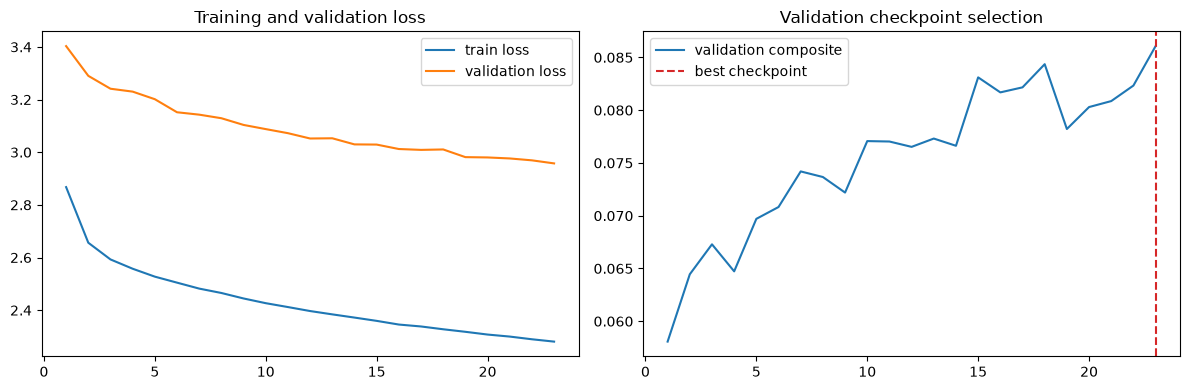

{'best_epoch': 23, 'final_train_minus_val_loss': -0.6769276708768688}


In [10]:
history = pd.DataFrame(metrics["history"])
display(history[["epoch", "loss", "val_loss", "composite"]])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["epoch"], history["loss"], label="train loss")
axes[0].plot(history["epoch"], history["val_loss"], label="validation loss")
axes[0].set_title("Training and validation loss")
axes[0].legend()
axes[1].plot(history["epoch"], history["composite"], label="validation composite")
axes[1].axvline(metrics["best_epoch"], color="#d62728", linestyle="--", label="best checkpoint")
axes[1].set_title("Validation checkpoint selection")
axes[1].legend()
plt.tight_layout()
plt.show()

best_row = history.loc[history["composite"].idxmax()]
overfit_gap = float(history.iloc[-1]["loss"] - history.iloc[-1]["val_loss"])
print({"best_epoch": int(metrics["best_epoch"]), "final_train_minus_val_loss": overfit_gap})


## Prediction

In [11]:
prediction_path = RUN_DIR / "predictions.jsonl"
predictions = [json.loads(line) for line in prediction_path.read_text(encoding="utf-8").splitlines() if line.strip()]
prediction = predictions[0]
display(pd.DataFrame([{
    "question": prediction["question"],
    "prediction": prediction["pred_answer"],
    "gold": prediction["gold_answers"],
    "score": prediction["score"],
    "error_slice": prediction["error_slice"],
}]))


,question,prediction,gold,score,error_slice
0,"What is the ‘actual’ value per 1000, during th...",0.2,[0.28],0.75,arithmetic_or_numeric_miss


## Metrics

In [12]:
test_payload = metrics["test"]
validation_vqa = metrics.get("vqa", {}).get("score", metrics.get("score"))
validation_r1 = metrics.get("retrieval", {}).get("mean_recall_at_k", {}).get("1", metrics.get("retrieval_mean_r1"))
test_vqa = test_payload.get("vqa", {}).get("score", test_payload.get("score"))
test_exact = test_payload.get("vqa", {}).get("exact_accuracy", test_payload.get("exact_accuracy"))
test_r1 = test_payload.get("retrieval", {}).get("mean_recall_at_k", {}).get("1", test_payload.get("retrieval_mean_r1"))
final_table = pd.DataFrame([{
    "dataset": DATASET,
    "architecture": ARCHITECTURE,
    "epochs_completed": metrics["epochs_completed"],
    "best_epoch": metrics["best_epoch"],
    "validation_vqa": validation_vqa,
    "validation_retrieval_r1": validation_r1,
    "test_vqa": test_vqa,
    "test_exact": test_exact,
    "test_retrieval_r1": test_r1,
    "status": metrics["status"],
    "full_training_was_run": metrics["training_execution"]["full_training_was_run"],
}])
display(final_table)
assert metrics["status"] == "completed_full"
assert metrics["training_execution"]["full_training_was_run"] is True
print("completed_full")


,dataset,architecture,epochs_completed,best_epoch,validation_vqa,validation_retrieval_r1,test_vqa,test_exact,test_retrieval_r1,status,full_training_was_run
0,docvqa,graphcolbert_film,23,23,0.151702,0.02044,0.0,0.0,0.018652,completed_full,True


completed_full
